In [1]:
import pandas as pd
df = pd.read_csv('heart_cleaned.csv')

In [2]:
from sklearn.model_selection import train_test_split

X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [3]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [4]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [5]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

models = {'Logistic Regression': log_model, 'Random Forest': rf_model}

for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"--- {name} ---")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))
    print()

--- Logistic Regression ---
Accuracy: 0.8533333333333334
Confusion Matrix:
 [[65 13]
 [ 9 63]]
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.83      0.86        78
           1       0.83      0.88      0.85        72

    accuracy                           0.85       150
   macro avg       0.85      0.85      0.85       150
weighted avg       0.85      0.85      0.85       150


--- Random Forest ---
Accuracy: 0.8666666666666667
Confusion Matrix:
 [[68 10]
 [10 62]]
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.87      0.87        78
           1       0.86      0.86      0.86        72

    accuracy                           0.87       150
   macro avg       0.87      0.87      0.87       150
weighted avg       0.87      0.87      0.87       150




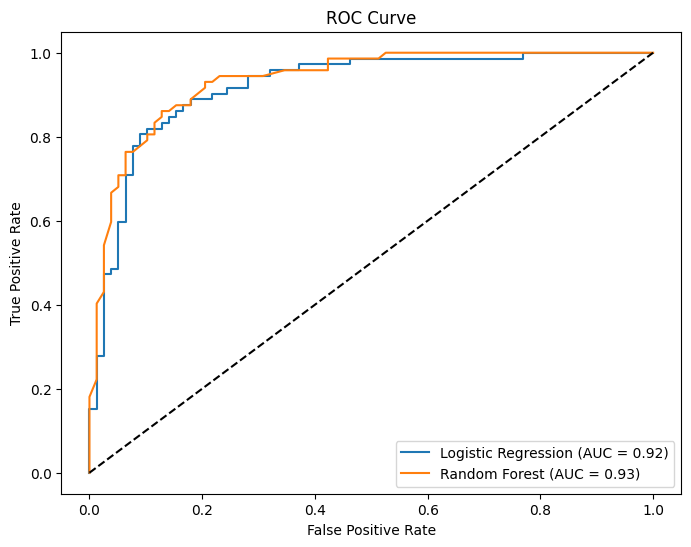

In [6]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.savefig("output_roc.png")
plt.show()

In [7]:
from sklearn.model_selection import cross_val_score

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5)
    print(f"{name} - Cross-validation Accuracy: {scores.mean():.2f} ± {scores.std():.2f}")

Logistic Regression - Cross-validation Accuracy: 0.85 ± 0.06
Random Forest - Cross-validation Accuracy: 0.86 ± 0.07


In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [9]:
proba = rf_model.predict_proba(X_test)[:, 1]
predictions = rf_model.predict(X_test)

results = pd.DataFrame({
    'Actual': y_test,
    'Predicted Class': predictions,
    'Probability of Heart Disease': proba
})

results.head(10)

results.to_csv("heart_disease_predictions.csv", index=False)

In [10]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy of the model: {accuracy:.2f}")


Accuracy of the model: 0.87


In [11]:
from sklearn.metrics import confusion_matrix

conf_matrix = confusion_matrix(y_test, predictions)
print("Confusion Matrix:")
print(conf_matrix)


Confusion Matrix:
[[68 10]
 [10 62]]


In [12]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(y_test, predictions))


Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.87      0.87        78
           1       0.86      0.86      0.86        72

    accuracy                           0.87       150
   macro avg       0.87      0.87      0.87       150
weighted avg       0.87      0.87      0.87       150

